discrepancia en los momentos 3 y 4 en smb y hml. dan tablas identicas por el rounding.

In [ ]:
import numpy as np
import pandas as pd

In [43]:
from config import RAW_DATA_DIR

df_raw = pd.read_csv(RAW_DATA_DIR / "dataset_paper1_monthly.csv",index_col="Date", parse_dates=True)
ffdata_df = df_raw.loc['1926-07-01':'2001-12-01', ['Mkt-RF', 'SMB', 'HML']]

In [44]:
ffdata_df

,Mkt-RF,SMB,HML
Date,,,
1926-07-01,2.89,-2.55,-2.39
1926-08-01,2.64,-1.14,3.81
1926-09-01,0.38,-1.36,0.05
1926-10-01,-3.27,-0.14,0.82
1926-11-01,2.54,-0.11,-0.61
...,...,...,...
2001-08-01,-6.40,2.19,2.86
2001-09-01,-9.24,-6.23,1.52
2001-10-01,2.48,7.49,-7.31


<Axes: xlabel='Date'>

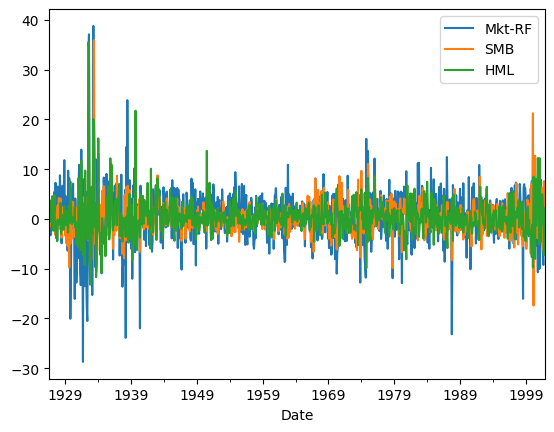

In [45]:
ffdata_df.plot()

In [46]:
T = [12, 24, 36, 48, 60, 125, 250, 500]
SR_base = np.arange(0.5, 3.25, 0.25)
desc = ['Mkt-RF', 'SMB', 'HML']

# 3. Cálculo de Sharpe Ratios iniciales
# mean / std (ddof=0 para desviación poblacional igual que en MATLAB)
SRdata = np.round(ffdata_df.mean() / ffdata_df.std(ddof=0) * 100) / 100
SR = np.concatenate((np.sort(SRdata.values), SR_base))

# 4. Tabla para la Distribución Normal
g3_norm, g4_norm = 0, 3
V_normal = 1 + 0.5 * SR**2

# Calculamos los errores estándar usando broadcasting de numpy
normalSEs = np.sqrt(V_normal[:, None] / np.array(T)[None, :])

# Creamos y mostramos el DataFrame de pandas
df_normals = pd.DataFrame(normalSEs, index=np.round(SR, 2), columns=T)
df_normals.index.name = 'SR'

print("\n" + "="*50)
print("--- TABLA: lotab1normals ---")
print("="*50)
print(df_normals.to_string(float_format=lambda x: f"{x:6.3f}"))
print(f"\n[Texto TeX]: Calculations based on values of $\\gamma 3={g3_norm:4.1f}$ and $\\gamma 4-3={g4_norm-3:4.1f}$ which match properties of normal distribution.\n")

# 5. Bucle para analizar y mostrar cada portafolio (RMRF, SMB, HML)
for i, col in enumerate(ffdata_df.columns):
    data = ffdata_df[col].values
    
    # Asimetría (g3) y Curtosis (g4) poblacional
    data_mean = np.mean(data)
    data_std = np.std(data, ddof=0)
    
    g3 = np.round(np.mean((data - data_mean)**3) / data_std**3)
    g4 = np.round(np.mean((data - data_mean)**4) / data_std**4)
    
    
    # Cálculo de errores estándar específicos
    V_data = 1 + 0.5 * SR**2 - g3 * SR + ((g4 - 3) / 4) * SR**2
    dataSEs = np.sqrt(V_data[:, None] / np.array(T)[None, :])
    
    # Creamos el DataFrame para los datos del factor
    df_factor = pd.DataFrame(dataSEs, index=np.round(SR, 2), columns=T)
    df_factor.index.name = 'SR'
    
    # Añadimos la columna del ratio (Error Estándar Normal / Error Estándar del Dato)
    ratio = (normalSEs[:, 0] / dataSEs[:, 0]) * 100
    df_factor['Ratio_T12(%)'] = ratio
    
    # Formateamos la salida
    datacomment = '(Simple monthly returns, 1926-2001)'
    formatters = {t: lambda x: f"{x:6.3f}" for t in T}
    formatters['Ratio_T12(%)'] = lambda x: f"{x:6.2f}%"
    
    print("\n" + "="*50)
    print(f"--- TABLA: lotab1 {desc[i]} ---")
    print("="*50)
    print(df_factor.to_string(formatters=formatters))
    print(f"\n[Texto TeX]: Calculations based on values of $\\gamma 3={g3:4.1f}$ and $\\gamma 4-3={g4-3:4.1f}$ which match properties of {desc[i]} portfolio {datacomment}. {desc[i]} itself has a Sharpe Ratio of {SRdata.iloc[i]:4.2f}.")


--- TABLA: lotab1normals ---
        12     24     36     48     60     125    250    500
SR                                                          
0.06  0.289  0.204  0.167  0.144  0.129  0.090  0.063  0.045
0.12  0.290  0.205  0.167  0.145  0.130  0.090  0.063  0.045
0.12  0.290  0.205  0.167  0.145  0.130  0.090  0.063  0.045
0.50  0.306  0.217  0.177  0.153  0.137  0.095  0.067  0.047
0.75  0.327  0.231  0.189  0.163  0.146  0.101  0.072  0.051
1.00  0.354  0.250  0.204  0.177  0.158  0.110  0.077  0.055
1.25  0.385  0.272  0.222  0.193  0.172  0.119  0.084  0.060
1.50  0.421  0.298  0.243  0.210  0.188  0.130  0.092  0.065
1.75  0.459  0.325  0.265  0.230  0.205  0.142  0.101  0.071
2.00  0.500  0.354  0.289  0.250  0.224  0.155  0.110  0.077
2.25  0.542  0.384  0.313  0.271  0.243  0.168  0.119  0.084
2.50  0.586  0.415  0.339  0.293  0.262  0.182  0.128  0.091
2.75  0.631  0.446  0.364  0.316  0.282  0.196  0.138  0.098
3.00  0.677  0.479  0.391  0.339  0.303  0.210  0.148  